In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,accuracy_score
from sklearn.model_selection import train_test_split
df=pd.read_csv(r'D:\Python\ML\Model\sms_spam\spam.csv',encoding='latin')

In [2]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df=df.iloc[:,:-3]
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [5]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [6]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(403)

In [8]:
df=df.drop_duplicates()

In [9]:
df.shape

(5169, 2)

In [10]:
df['target'].value_counts()

target
ham     4516
spam     653
Name: count, dtype: int64

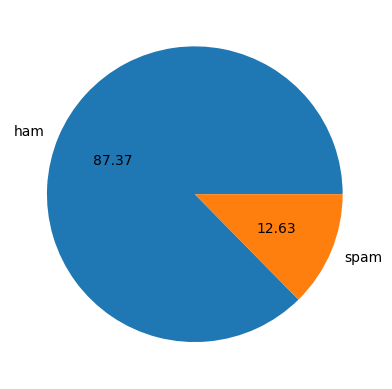

In [11]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [12]:
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
df['num_char']=df['text'].apply(len)

In [13]:
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [14]:
df['num_sent']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [15]:
df

,target,text,num_char,num_words,num_sent
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [16]:
df[df['target']=='ham']

,target,text,num_char,num_words,num_sent
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
6,ham,Even my brother is not like to speak with me. ...,77,18,2
...,...,...,...,...,...
5565,ham,Huh y lei...,12,4,1
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [17]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['target']=encoder.fit_transform(df['target'])

In [18]:
df[df['target']==0][["num_char","num_words","num_sent"]].describe()

,num_char,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


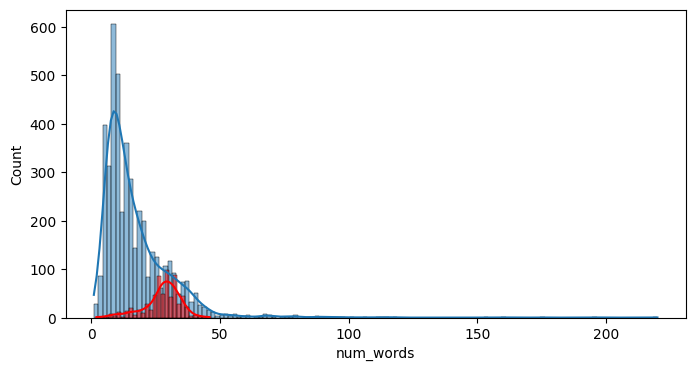

In [19]:
plt.figure(figsize=(8,4))
sns.histplot(df[df['target']==0]['num_words'],kde=True)
sns.histplot(df[df['target']==1]['num_words'],kde=True,color='r')
plt.show()

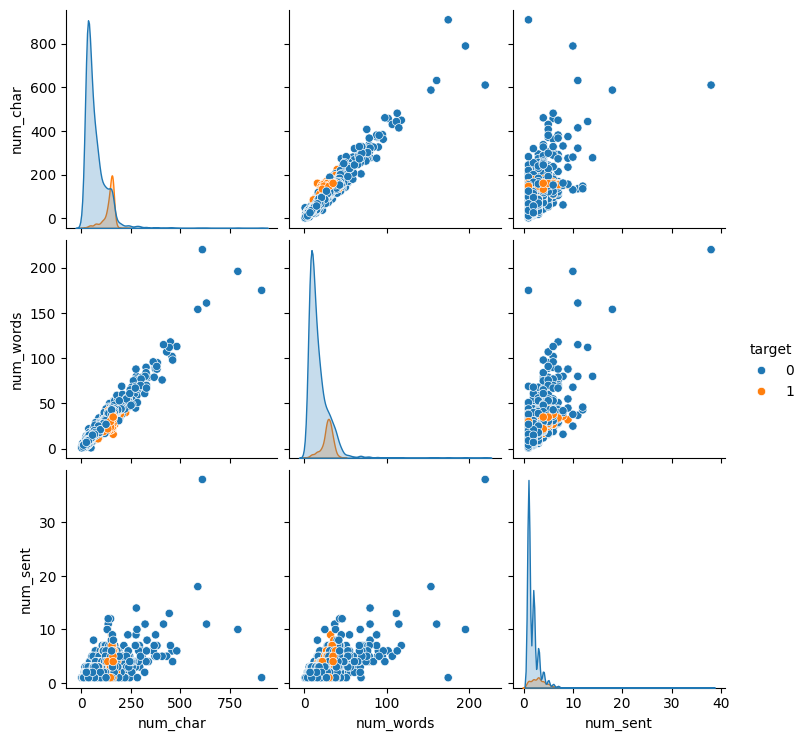

In [20]:
sns.pairplot(data=df,hue='target')
plt.show()

<Axes: >

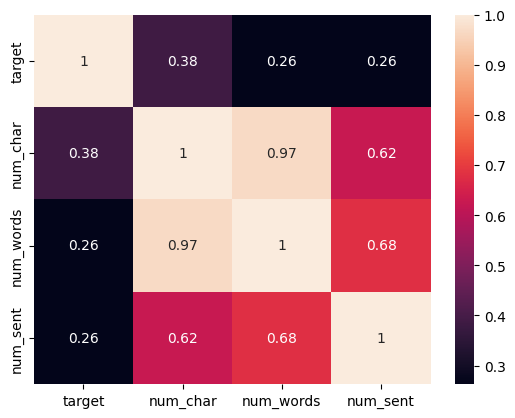

In [21]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [22]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
ps=PorterStemmer()
stop_words=set(stopwords.words('english'))
def preprocess(text):
    tokens=word_tokenize(str(text).lower())
    tokens=[word for word in tokens if word.isalnum()]
    tokens=[word for word in tokens if word not in stop_words]
    tokens=[ps.stem(word) for word in tokens]
    return " ".join(tokens)


In [23]:
df['transformed_text']=df['text'].apply(preprocess)

In [24]:
df.head()

,target,text,num_char,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [25]:
from wordcloud import WordCloud

In [26]:
wc=WordCloud(width=500, height=500, min_font_size=10, background_color='white')
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

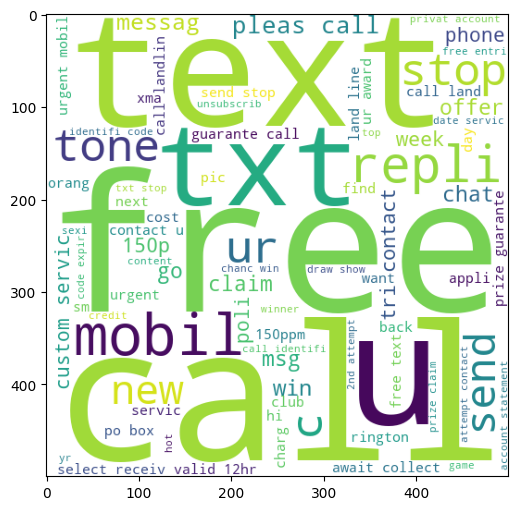

In [27]:
plt.figure(figsize=(12,6))
plt.imshow(spam_wc)

In [28]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

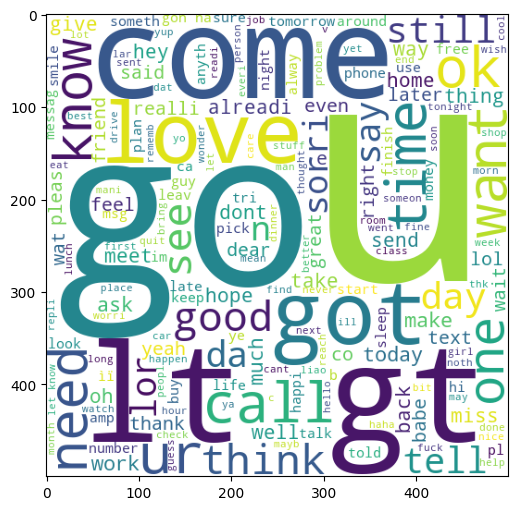

In [29]:
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)

In [30]:
from collections import Counter
spam_corpus=df[df['target']==1]['transformed_text'].tolist()
spam_words=Counter([word for sentence in spam_corpus for word in sentence.split()])
ham_corpus=df[df['target']==0]['transformed_text'].tolist()
ham_words=Counter([word for sentence in ham_corpus for word in sentence.split()])

In [31]:
spam_df=pd.DataFrame(spam_words.most_common(30),columns=["word",'count'])
ham_df=pd.DataFrame(ham_words.most_common(30),columns=["word",'count'])

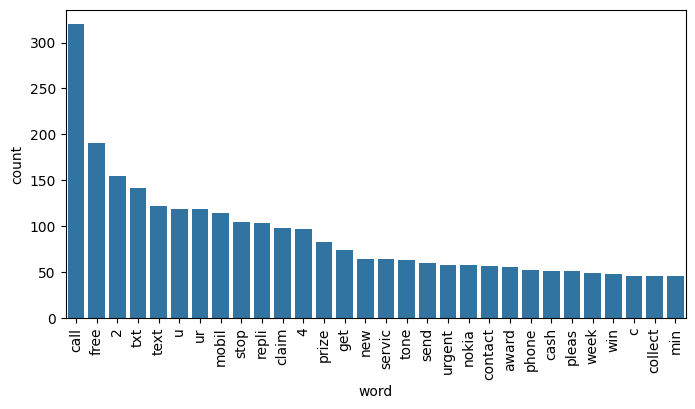

In [32]:
plt.figure(figsize=(8,4))
sns.barplot(data=spam_df,x='word',y='count')
plt.xticks(rotation='vertical')
plt.show()

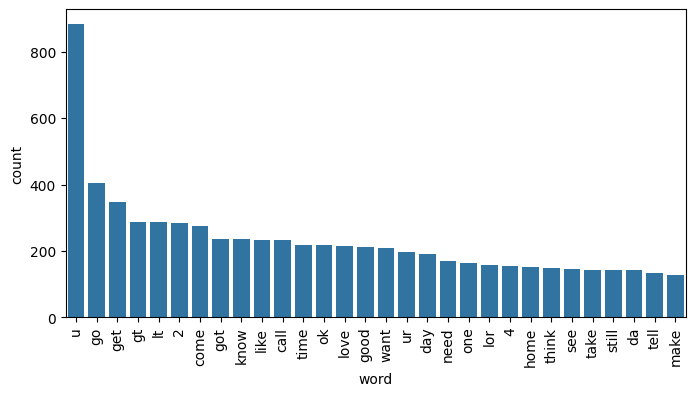

In [33]:
plt.figure(figsize=(8,4))
sns.barplot(data=ham_df,x='word',y='count')
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tv=TfidfVectorizer()

In [69]:
X=df['transformed_text']
y=df['target'].values


In [75]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [76]:
X_train=tv.fit_transform(X_train)
X_test=tv.transform(X_test)

In [82]:
X_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7429 stored elements and shape (1034, 5936)>

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier, BaggingClassifier,ExtraTreesClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [78]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
gnb=GaussianNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver='liblinear',penalty='l1')
rfc=RandomForestClassifier(n_estimators=50,random_state=2)
abc=AdaBoostClassifier(n_estimators=50,random_state=2)
bc=BaggingClassifier(n_estimators=50,random_state=2)
etc=ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt=GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb=XGBClassifier(n_estimators=50,random_state=2)

In [84]:
cls={'SVC':svc,
     'KN':knc,
     'NB':mnb,
     'DT':dtc,
     'LR':lrc,
     'RF':rfc,
     'Adaboost':abc,
     'BgC':bc,
     'ETC':etc,
     'GBDT':gbdt,
     'XGB':xgb}

In [85]:
results=[]
for name, clf in cls.items():
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results.append([name,accuracy,precision,recall,f1])

c:\Users\haris\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\haris\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [86]:
performance_df=pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1'])
print(performance_df.sort_values('F1',ascending=False))

       Model  Accuracy  Precision    Recall        F1
0        SVC  0.977756   0.942029  0.896552  0.918728
8        ETC  0.973888   0.975806  0.834483  0.899628
5         RF  0.972921   0.991597  0.813793  0.893939
10       XGB  0.961315   0.948718  0.765517  0.847328
2         NB  0.962282   0.990741  0.737931  0.845850
7        BgC  0.957447   0.885496  0.800000  0.840580
4         LR  0.949710   0.866142  0.758621  0.808824
9       GBDT  0.948743   0.950980  0.668966  0.785425
3         DT  0.930368   0.823009  0.641379  0.720930
6   Adaboost  0.914894   0.820225  0.503448  0.623932
1         KN  0.899420   1.000000  0.282759  0.440860


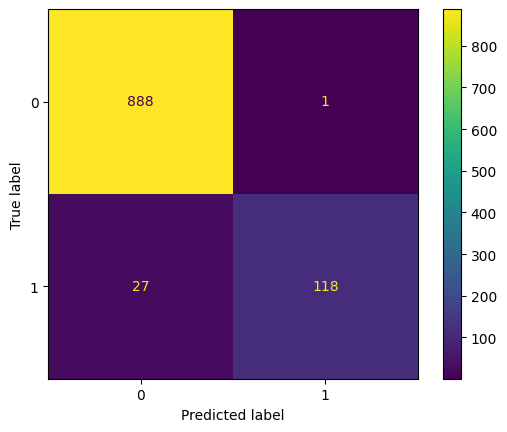

In [87]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
best_model=rfc
y_pred=best_model.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [89]:
msg = "Congratulations! You have won a free lottery. Claim now."

vector = tv.transform([msg])

prediction = svc.predict(vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Spam
